# Titanic Dataset Cleaning and Visualization

## Objective

The objective of this project is to perform data preprocessing and visualization on the Titanic dataset. The analysis focuses on handling missing values, encoding categorical variables, normalizing numerical features, and generating insights related to passenger survival.

## 1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.max_columns", None)

Libraries imported successfully.


## 2. Load Dataset

In [2]:
df = pd.read_csv("../data/train.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 3. Dataset Preview

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 4. Dataset Dimensions

In [4]:
rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")

Number of Rows    : 891
Number of Columns : 12


## 5. Dataset Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 6. Missing Values Analysis

Identifying missing values is an important preprocessing step because incomplete data can negatively impact analysis and machine learning performance.

In [6]:
missing_values = df.isnull().sum()

missing_values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage.sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

## 7. Missing Value Treatment

Missing values were handled using appropriate strategies based on the nature of each feature.

In [8]:
# Fill Age using median because age is a numeric value hence outliers can be there

df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

In [9]:
# Fill Embarked using mode

df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

In [10]:
# Drop Cabin column

df.drop(
    columns=["Cabin"],
    inplace=True
)

In [11]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 8. Encoding Categorical Variables

Machine learning algorithms require numerical input. Therefore, categorical features are converted into numerical representations.

In [12]:
sex_encoder = LabelEncoder()

df["Sex"] = sex_encoder.fit_transform(
    df["Sex"]
)

df["Sex"].head()

0    1
1    0
2    0
3    0
4    1
Name: Sex, dtype: int64

In [13]:
print(sex_encoder.classes_)

['female' 'male']


In [14]:
embarked_encoder = LabelEncoder()

df["Embarked"] = embarked_encoder.fit_transform(
    df["Embarked"]
)

print(embarked_encoder.classes_)

['C' 'Q' 'S']


In [15]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,2


## 9. Feature Selection

Columns such as Name and Ticket contain unique identifiers and text information that do not directly contribute to survival analysis. Therefore, these columns were removed.

In [16]:
df.drop(
    columns=["Name", "Ticket"],
    inplace=True
)

df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,1,22.0,1,0,7.2500,2
1,2,1,1,0,38.0,1,0,71.2833,0
2,3,1,3,0,26.0,0,0,7.9250,2
3,4,1,1,0,35.0,1,0,53.1000,2
4,5,0,3,1,35.0,0,0,8.0500,2


## 10. Feature Normalization

Age and Fare were normalized using Min-Max Scaling to bring numerical values into a common range between 0 and 1.

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[["Age", "Fare"]] = scaler.fit_transform(
    df[["Age", "Fare"]]
)

In [18]:
df[["Age", "Fare"]].head()

,Age,Fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


In [19]:
df.to_csv(
    "../data/titanic_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## 11. Survival Distribution

This visualization shows the number of passengers who survived and those who did not survive the Titanic disaster.

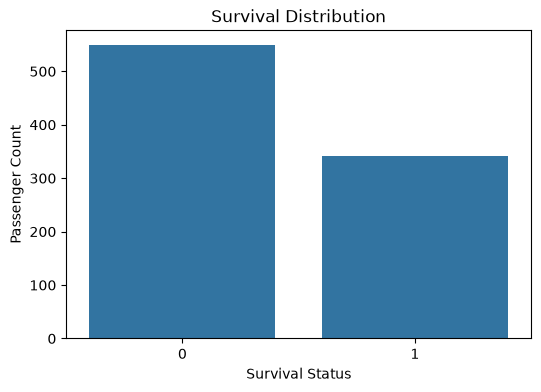

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Survived",
    data=df
)

plt.title("Survival Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Passenger Count")

plt.show()

## 12. Gender Ratios

This visualization shows the distribution of male and female passengers in the dataset.

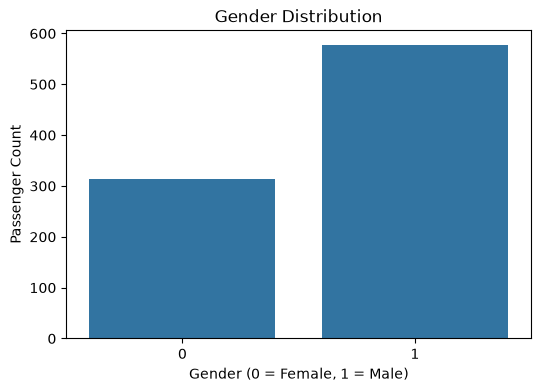

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Sex",
    data=df
)

plt.title("Gender Distribution")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Passenger Count")

plt.show()

## 13. Gender vs Survival

This visualization examines how passenger gender influenced survival outcomes.

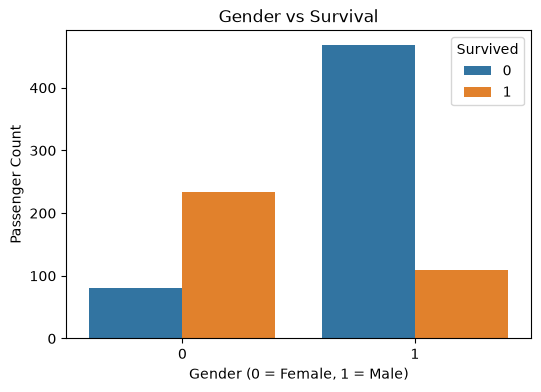

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Sex",
    hue="Survived",
    data=df
)

plt.title("Gender vs Survival")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Passenger Count")

plt.show()

## 14. Passenger Class vs Survival

This visualization explores the relationship between passenger class and survival rates.

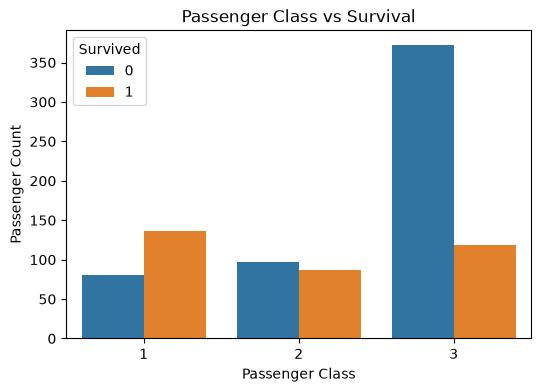

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Pclass",
    hue="Survived",
    data=df
)

plt.title("Passenger Class vs Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Passenger Count")

plt.show()

## 15. Age and Survival

This visualization compares passenger age distributions across survival outcomes.

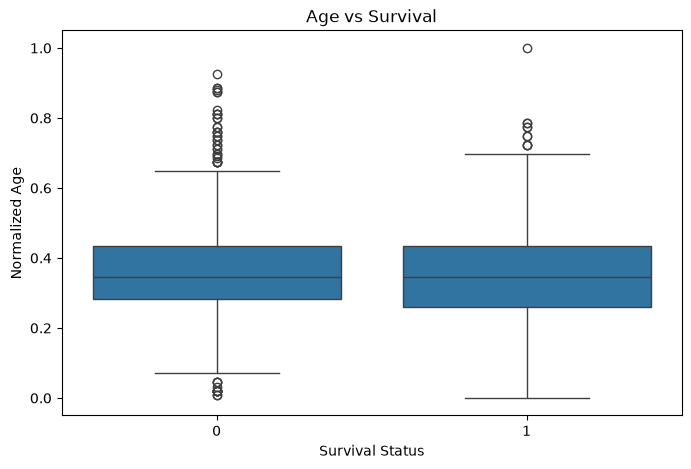

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Survived",
    y="Age",
    data=df
)

plt.title("Age vs Survival")
plt.xlabel("Survival Status")
plt.ylabel("Normalized Age")

plt.show()

## 16. Fare Distribution

This visualization illustrates the distribution of ticket fares paid by passengers.

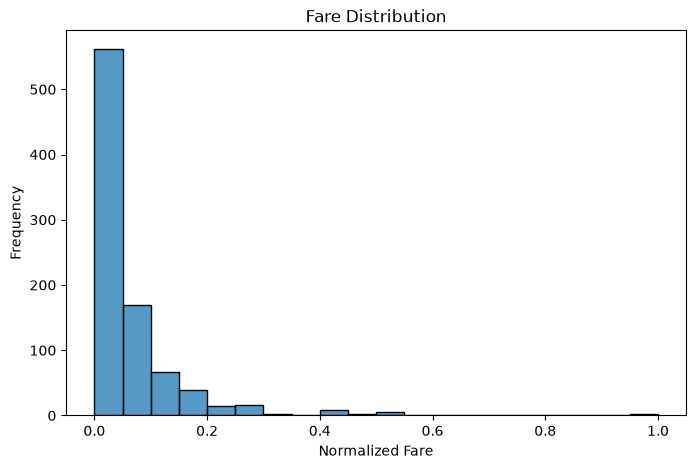

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Fare"],
    bins=20
)

plt.title("Fare Distribution")
plt.xlabel("Normalized Fare")
plt.ylabel("Frequency")

plt.show()

## 17. Key Findings

### Finding 1
Female passengers had significantly higher survival rates than male passengers.

### Finding 2
Passengers traveling in first class were more likely to survive compared to passengers in lower classes.

### Finding 3
Passenger class was an important factor influencing survival probability.

### Finding 4
Age alone did not strongly determine survival, although survival patterns varied across age groups.

### Finding 5
Passengers paying higher fares generally belonged to higher classes, which were associated with better survival outcomes.

## 18. Conclusion

This project involved preprocessing and analyzing the Titanic dataset using Python, Pandas, Matplotlib, Seaborn, and Scikit-learn.

Missing values were handled, categorical variables were encoded, numerical features were normalized, and multiple visualizations were created to study passenger survival patterns.

The analysis revealed that gender, passenger class, and ticket fare were important factors associated with survival outcomes. These findings demonstrate how data preprocessing and visualization can be used to extract meaningful insights from real-world datasets.